In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
DATA_PATH = r"D:\projects\AI-Stock-Analytics-System\data\final\feature_engineered_stock_data.csv"

df = pd.read_csv(DATA_PATH)

In [4]:
df.shape

(475258, 28)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 475258 entries, 0 to 475257
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date            475258 non-null  object 
 1   Close           475258 non-null  float64
 2   High            475258 non-null  float64
 3   Low             475258 non-null  float64
 4   Open            475258 non-null  float64
 5   Volume          475258 non-null  float64
 6   Ticker          475258 non-null  object 
 7   Daily_Return    475258 non-null  float64
 8   MA5             475258 non-null  float64
 9   MA10            475258 non-null  float64
 10  MA20            475258 non-null  float64
 11  MA50            475258 non-null  float64
 12  EMA20           475258 non-null  float64
 13  RSI             475258 non-null  float64
 14  EMA12           475258 non-null  float64
 15  EMA26           475258 non-null  float64
 16  MACD            475258 non-null  float64
 17  Signal_Lin

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 475258 entries, 0 to 475257
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            475258 non-null  datetime64[ns]
 1   Close           475258 non-null  float64       
 2   High            475258 non-null  float64       
 3   Low             475258 non-null  float64       
 4   Open            475258 non-null  float64       
 5   Volume          475258 non-null  float64       
 6   Ticker          475258 non-null  object        
 7   Daily_Return    475258 non-null  float64       
 8   MA5             475258 non-null  float64       
 9   MA10            475258 non-null  float64       
 10  MA20            475258 non-null  float64       
 11  MA50            475258 non-null  float64       
 12  EMA20           475258 non-null  float64       
 13  RSI             475258 non-null  float64       
 14  EMA12           475258 non-null  flo

In [8]:
feature_columns = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume",
    "Daily_Return",
    "MA5",
    "MA10",
    "MA20",
    "MA50",
    "EMA20",
    "RSI",
    "EMA12",
    "EMA26",
    "MACD",
    "Signal_Line",
    "MACD_Histogram",
    "Upper_Band",
    "Lower_Band",
    "Volatility",
    "Lag1",
    "Lag2",
    "Lag3"
]

In [10]:
X_reg = df[feature_columns]
y_reg = df["Target_Close"]

In [11]:
X_clf = df[feature_columns]
y_clf = df["Target_Signal"]

In [13]:
df = df.sort_values(
    ["Date", "Ticker"]
).reset_index(drop=True)

In [14]:
print("Start Date :", df["Date"].min())
print("End Date   :", df["Date"].max())

Start Date : 2005-03-15 00:00:00
End Date   : 2026-07-24 00:00:00


In [15]:
split_date = "2024-01-01"

In [16]:
X_train_reg = X_reg[
    df["Date"] < split_date]
X_test_reg = X_reg[
    df["Date"] >= split_date]
y_train_reg = y_reg[
    df["Date"] < split_date]
y_test_reg = y_reg[
    df["Date"] >= split_date]

In [17]:
X_train_clf = X_clf[
    df["Date"] < split_date]
X_test_clf = X_clf[
    df["Date"] >= split_date]
y_train_clf = y_clf[
    df["Date"] < split_date]
y_test_clf = y_clf[
    df["Date"] >= split_date]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [20]:
X_train_reg_scaled = scaler.fit_transform(X_train_reg)

In [21]:
X_test_reg_scaled = scaler.transform(X_test_reg)

In [26]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [27]:
baseline_pred = X_test_reg["Close"]

In [28]:
import numpy as np
baseline_mae = mean_absolute_error(
    y_test_reg,
    baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        baseline_pred))
baseline_r2 = r2_score(
    y_test_reg,
    baseline_pred)
print(f"Baseline MAE : {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²  : {baseline_r2:.4f}")

Baseline MAE : 9.41
Baseline RMSE: 26.26
Baseline R²  : 0.9997


In [29]:
regression_results = pd.DataFrame(
    columns=["Model", "MAE", "RMSE", "R2"])
regression_results.loc[len(regression_results)] = [
    "Baseline",
    baseline_mae,
    baseline_rmse,
    baseline_r2]
regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.414568,26.262907,0.999707


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr = LinearRegression()
lr.fit(
    X_train_reg_scaled,
    y_train_reg
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
lr_pred = lr.predict(
    X_test_reg_scaled
)

In [34]:
lr_mae = mean_absolute_error(
    y_test_reg,
    lr_pred)
lr_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        lr_pred))
lr_r2 = r2_score(
    y_test_reg,
    lr_pred)
print(f"Linear Regression MAE  : {lr_mae:.2f}")
print(f"Linear Regression RMSE : {lr_rmse:.2f}")
print(f"Linear Regression R²   : {lr_r2:.4f}")

Linear Regression MAE  : 9.45
Linear Regression RMSE : 26.26
Linear Regression R²   : 0.9997


In [35]:
regression_results.loc[len(regression_results)] = [
    "Linear Regression",
    lr_mae,
    lr_rmse,
    lr_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.414568,26.262907,0.999707
1,Linear Regression,9.450966,26.258621,0.999708


In [36]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [37]:
param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]}

In [38]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

In [39]:
ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [40]:
ridge_search.fit(
    X_train_reg_scaled,
    y_train_reg
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [41]:
print("Best Alpha:", ridge_search.best_params_)

Best Alpha: {'alpha': 0.01}


In [42]:
best_ridge = ridge_search.best_estimator_

In [43]:
ridge_pred = best_ridge.predict(
    X_test_reg_scaled
)

In [44]:
ridge_mae = mean_absolute_error(
    y_test_reg,
    ridge_pred)
ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        ridge_pred))
ridge_r2 = r2_score(
    y_test_reg,
    ridge_pred)
print(f"Ridge MAE  : {ridge_mae:.2f}")
print(f"Ridge RMSE : {ridge_rmse:.2f}")
print(f"Ridge R²   : {ridge_r2:.4f}")

Ridge MAE  : 9.45
Ridge RMSE : 26.26
Ridge R²   : 0.9997


In [45]:
regression_results.loc[len(regression_results)] = [
    "Ridge Regression",
    ridge_mae,
    ridge_rmse,
    ridge_r2]
regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.414568,26.262907,0.999707
1,Linear Regression,9.450966,26.258621,0.999708
2,Ridge Regression,9.450434,26.258368,0.999708


In [52]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.001, max_iter=10000)

lasso.fit(X_train_reg_scaled, y_train_reg)

lasso_pred = lasso.predict(X_test_reg_scaled)

In [53]:
print(X_train_reg.shape)
print(X_test_reg.shape)

(411066, 23)
(64192, 23)


In [54]:
lasso_mae = mean_absolute_error(
    y_test_reg,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        lasso_pred
    )
)

lasso_r2 = r2_score(
    y_test_reg,
    lasso_pred
)

print(f"Lasso MAE  : {lasso_mae:.2f}")
print(f"Lasso RMSE : {lasso_rmse:.2f}")
print(f"Lasso R²   : {lasso_r2:.4f}")

Lasso MAE  : 9.45
Lasso RMSE : 26.26
Lasso R²   : 0.9997


In [55]:
regression_results.loc[len(regression_results)] = [
    "Lasso Regression",
    lasso_mae,
    lasso_rmse,
    lasso_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.414568,26.262907,0.999707
1,Linear Regression,9.450966,26.258621,0.999708
2,Ridge Regression,9.450434,26.258368,0.999708
3,Lasso Regression,9.445844,26.257375,0.999708


In [56]:
coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": lasso.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute",
    ascending=False
)

coefficients 

,Feature,Coefficient,Absolute
0,Close,2821.427552,2821.427552
22,Lag3,-33.156883,33.156883
6,MA5,-11.948124,11.948124
9,MA50,-9.324035,9.324035
2,Low,-8.567926,8.567926
8,MA20,5.775990,5.775990
10,EMA20,4.328539,4.328539
17,Upper_Band,3.533485,3.533485
18,Lower_Band,3.495483,3.495483
1,High,-3.045287,3.045287


In [57]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42)
dt.fit(
    X_train_reg,
    y_train_reg)
dt_pred = dt.predict(
    X_test_reg)
dt_mae = mean_absolute_error(
    y_test_reg,
    dt_pred)
dt_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        dt_pred))
dt_r2 = r2_score(
    y_test_reg,
    dt_pred)
print(f"Decision Tree MAE  : {dt_mae:.2f}")
print(f"Decision Tree RMSE : {dt_rmse:.2f}")
print(f"Decision Tree R²   : {dt_r2:.4f}")

Decision Tree MAE  : 10.32
Decision Tree RMSE : 29.27
Decision Tree R²   : 0.9996


In [58]:
regression_results.loc[len(regression_results)] = [
    "Decision Tree",
    dt_mae,
    dt_rmse,
    dt_r2]
regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.414568,26.262907,0.999707
1,Linear Regression,9.450966,26.258621,0.999708
2,Ridge Regression,9.450434,26.258368,0.999708
3,Lasso Regression,9.445844,26.257375,0.999708
4,Decision Tree,10.322823,29.270045,0.999637


In [59]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": dt.feature_importances_})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False)
feature_importance

,Feature,Importance
0,Close,9.999085e-01
2,Low,3.739269e-05
21,Lag2,5.229955e-06
1,High,5.059753e-06
19,Volatility,4.601488e-06
11,RSI,3.917547e-06
15,Signal_Line,3.613926e-06
4,Volume,3.598527e-06
16,MACD_Histogram,3.503499e-06
14,MACD,3.310742e-06


In [60]:
from sklearn.ensemble import RandomForestRegressor


In [61]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1)

In [62]:
rf.fit(
    X_train_reg,
    y_train_reg
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [63]:
rf_pred = rf.predict(
    X_test_reg)

In [64]:
rf_mae = mean_absolute_error(
    y_test_reg,
    rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        rf_pred))
rf_r2 = r2_score(
    y_test_reg,
    rf_pred)
print(f"Random Forest MAE  : {rf_mae:.2f}")
print(f"Random Forest RMSE : {rf_rmse:.2f}")
print(f"Random Forest R²   : {rf_r2:.4f}")

Random Forest MAE  : 9.75
Random Forest RMSE : 27.26
Random Forest R²   : 0.9997


In [65]:
regression_results.loc[len(regression_results)] = [
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.414568,26.262907,0.999707
1,Linear Regression,9.450966,26.258621,0.999708
2,Ridge Regression,9.450434,26.258368,0.999708
3,Lasso Regression,9.445844,26.257375,0.999708
4,Decision Tree,10.322823,29.270045,0.999637
5,Random Forest,9.747764,27.263031,0.999685


In [66]:
rf_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
0,Close,0.997300
2,Low,0.002228
1,High,0.000386
19,Volatility,0.000007
4,Volume,0.000006
3,Open,0.000006
11,RSI,0.000005
16,MACD_Histogram,0.000005
5,Daily_Return,0.000005
21,Lag2,0.000005


In [68]:
!pip install xgboost
import xgboost


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 1.8/69.5 MB 14.4 MB/s eta 0:00:05
   -- ------------------------------------- 5.0/69.5 MB 15.9 MB/s eta 0:00:05
   ---- ----------------------------------- 7.3/69.5 MB 14.6 MB/s eta 0:00:05
   ----- ---------------------------------- 10.0/69.5 MB 13.8 MB/s eta 0:00:05
   ------- -------------------------------- 12.3/69.5 MB 13.3 MB/s eta 0:00:05
   -------- ------------------------------- 15.2/69.5 MB 13.1 MB/s eta 0:00:05
   ---------- ----------------------------- 17.6/69.5 MB 13.0 MB/s eta 0:00:04
   ----------- ---------------------------- 20.2/69.5 MB 12.9 MB/s eta 0:00:04
   ------------ --------------------------- 22.5/69.5 MB 12.9 MB/s eta 0:00:04
   -------------- ------------------------- 25.2/69.5 MB 12.8 MB/s eta 0:00:04
   --------------- ------------------------ 27.8/69.5 MB 12.7 MB/s eta 0:00:04
   ----------------- ---------------------- 30.4/69.5 MB 12.6 MB

In [69]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror")
xgb.fit(
    X_train_reg,
    y_train_reg)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [70]:
xgb_pred = xgb.predict(X_test_reg)

In [71]:
xgb_mae = mean_absolute_error(
    y_test_reg,
    xgb_pred)
xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        xgb_pred))
xgb_r2 = r2_score(
    y_test_reg,
    xgb_pred)
print(f"XGBoost MAE  : {xgb_mae:.2f}")
print(f"XGBoost RMSE : {xgb_rmse:.2f}")
print(f"XGBoost R²   : {xgb_r2:.4f}")

XGBoost MAE  : 18.49
XGBoost RMSE : 87.45
XGBoost R²   : 0.9968


In [72]:
regression_results.loc[len(regression_results)] = [
    "XGBoost",
    xgb_mae,
    xgb_rmse,
    xgb_r2
]

regression_results

,Model,MAE,RMSE,R2
0,Baseline,9.414568,26.262907,0.999707
1,Linear Regression,9.450966,26.258621,0.999708
2,Ridge Regression,9.450434,26.258368,0.999708
3,Lasso Regression,9.445844,26.257375,0.999708
4,Decision Tree,10.322823,29.270045,0.999637
5,Random Forest,9.747764,27.263031,0.999685
6,XGBoost,18.488080,87.449738,0.996757


In [73]:
from sklearn.metrics import r2_score
train_pred = xgb.predict(X_train_reg)
print("Train R2 :", r2_score(y_train_reg, train_pred))
print("Test R2  :", r2_score(y_test_reg, xgb_pred))

Train R2 : 0.9960519437187146
Test R2  : 0.9967567117610231


In [74]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": xgb.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,Open,0.302610
2,Low,0.182472
0,Close,0.172162
21,Lag2,0.129958
22,Lag3,0.079326
1,High,0.032428
17,Upper_Band,0.027840
9,MA50,0.021487
20,Lag1,0.018303
18,Lower_Band,0.016036


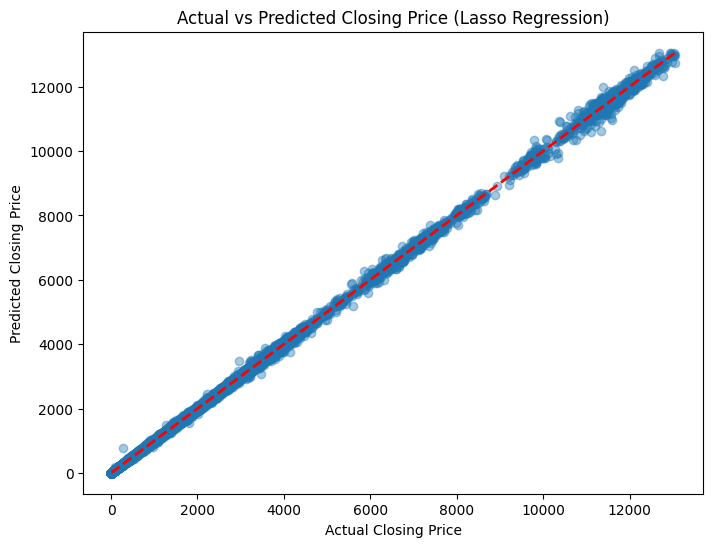

In [75]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(
    y_test_reg,
    lasso_pred,
    alpha=0.4)
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    color="red",
    linestyle="--",
    linewidth=2)
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Closing Price (Lasso Regression)")
plt.show()

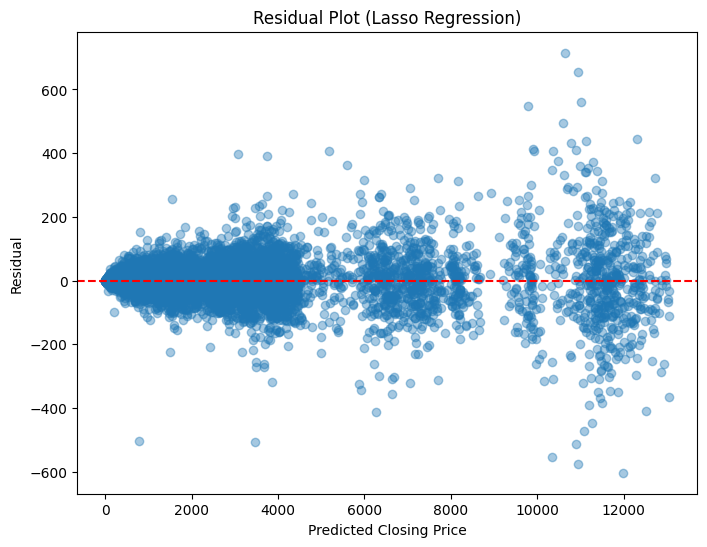

In [76]:
residuals = y_test_reg - lasso_pred
plt.figure(figsize=(8,6))
plt.scatter(
    lasso_pred,
    residuals,
    alpha=0.4)
plt.axhline(
    y=0,
    color="red",
    linestyle="--")
plt.xlabel("Predicted Closing Price")
plt.ylabel("Residual")
plt.title("Residual Plot (Lasso Regression)")
plt.show()

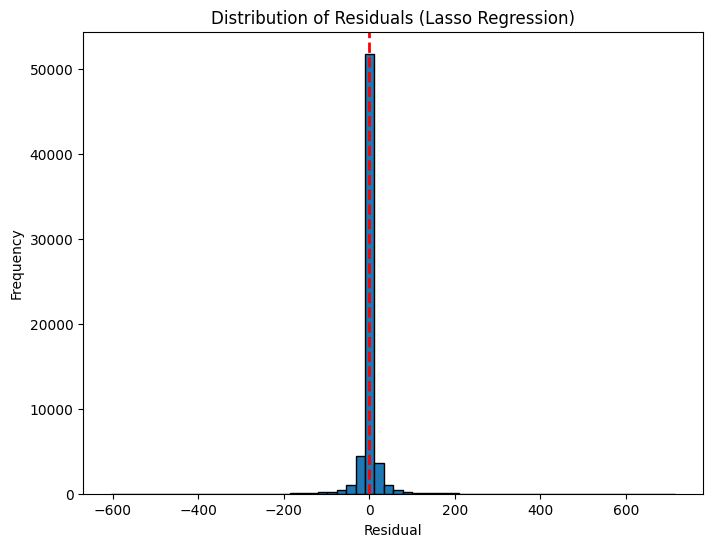

In [78]:
plt.figure(figsize=(8,6))
plt.hist(
    residuals,
    bins=60,
    edgecolor="black")
plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (Lasso Regression)")
plt.show()

In [80]:
import joblib

joblib.dump(
    lasso,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_lasso.pkl"
)

print("Regression model saved successfully.")

Regression model saved successfully.


In [81]:
joblib.dump(
    scaler,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_scaler.pkl"
)

print("Regression scaler saved successfully.")

Regression scaler saved successfully.


In [82]:
joblib.dump(
    feature_columns,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_features.pkl"
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [83]:
regression_metadata = {
    "model_name": "Lasso Regression",
    "mae": lasso_mae,
    "rmse": lasso_rmse,
    "r2": lasso_r2,
    "target": "Target_Close"}
joblib.dump(
    regression_metadata,
    r"D:\projects\AI-Stock-Analytics-System\models\trained_models\regression\regression_metadata.pkl")
print("Regression metadata saved successfully.")

Regression metadata saved successfully.
